## Imports

In [1]:
import sys
!{sys.executable} -m pip install \
scikit-learn \
matplotlib \
numpy \
qiskit \
qiskit-aer \
pennylane



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Bibliotecas

In [2]:
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import pennylane as qml
from pennylane import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from pennylane.templates import BasicEntanglerLayers
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    average_precision_score,
    classification_report
)

##

# Criação de uma base de dados com 2 classes
## primeira base com dados lineares

dados lineares: dados que podem ser separados por uma reta

In [3]:
x_linear, y = make_blobs(n_samples = 400, centers = 2, n_features= 2, cluster_std = 1, random_state = 42) #geracao de dados lineares com duas classes

### Visualização dos dados

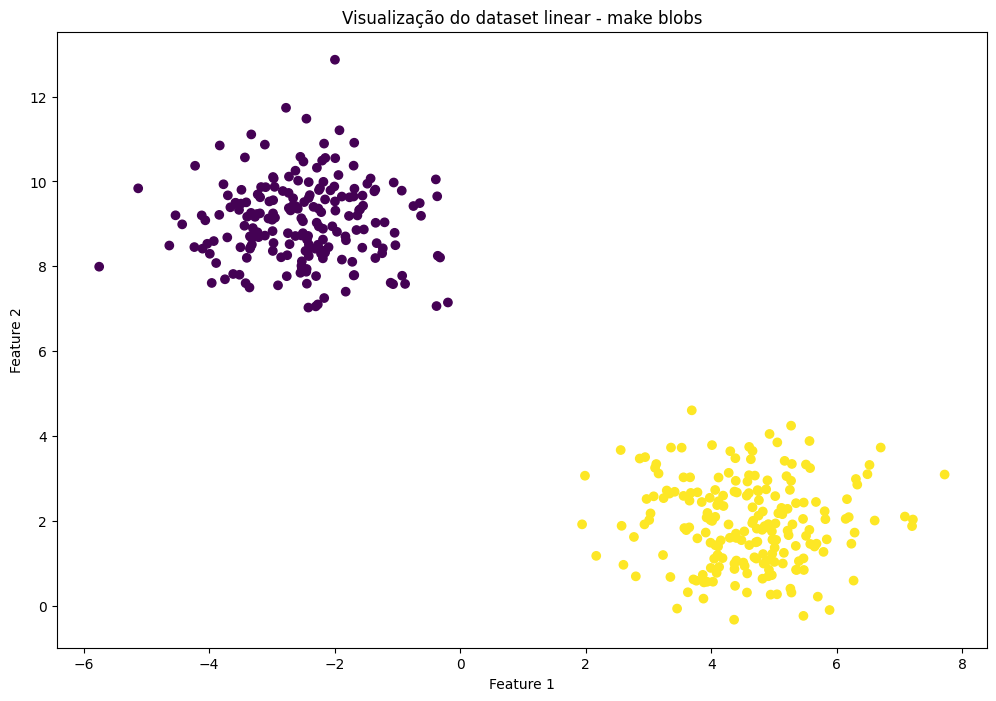

In [4]:
plt.figure(figsize=(12, 8))

plt.scatter(x_linear[:, 0], x_linear[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Visualização do dataset linear - make blobs")

plt.show()

# **Encoding**: $\text{Mapeamento de dados clássicos para estados quânticos}$


### Reescalando os dados originais para o intervalo angular [0, π], convertendo cada feature proporcionalmente em radianos, dessa forma permitindo rotações estáveis e adequadas nos qubits durante o embedding quântico

$$
x' = \pi \frac{x - \min}{\max - \min}
$$

In [5]:
scaler = MinMaxScaler(feature_range=(0, np.pi)) #escalonamento dos dados para o intervalo de 0 a pi, para que possam ser usados como ângulos em um circuito quântico
X_angulos = scaler.fit_transform(x_linear) #aplicação do escalonamento aos dados lineares

### Visualização dos dados

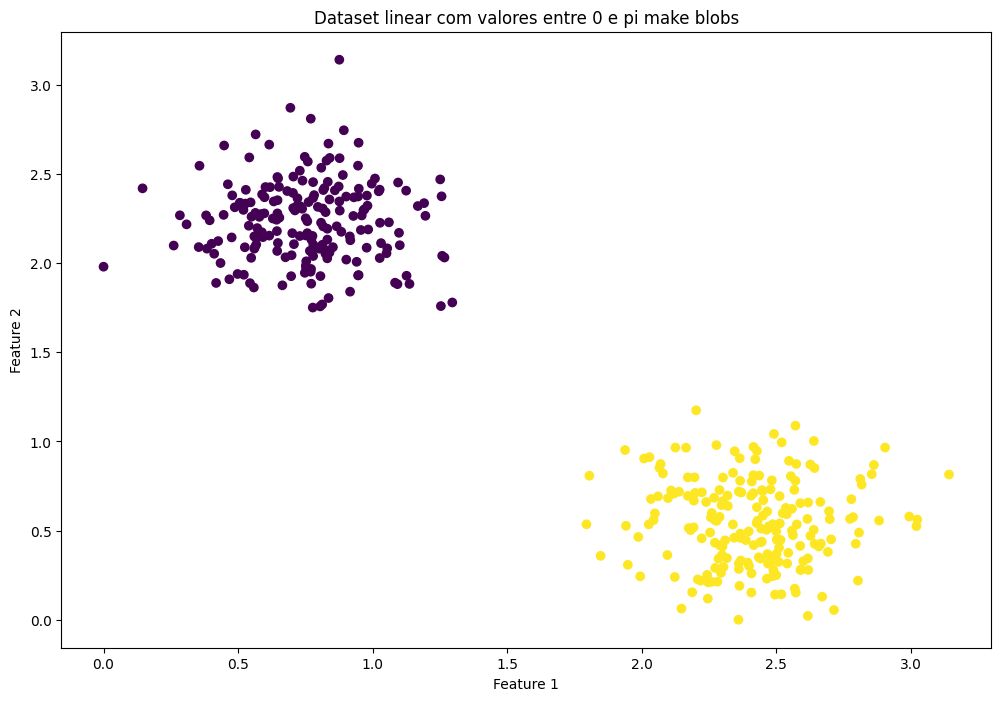

In [6]:
plt.figure(figsize=(12, 8))

plt.scatter(X_angulos[:, 0], X_angulos[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset linear com valores entre 0 e pi make blobs")

plt.show()


## Separando os Dados para treino e teste

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_angulos, y,
    test_size=0.2,      # 20% teste
    random_state=42,    # reprodutibilidade
    shuffle=True        # embaralhar
)

# **Ansatz Variacional**: $\text{aplicação de um circuito parametrizado com pesos ajustáveis}$


## Definição do dispositivo Quântico com 2 Qubits, onde cada Qubit vai representar uma freature

In [ ]:
dev = qml.device("default.qubit", wires=2) #criando um dispositivo quantico com 2 qubits, cada qubit representará uma das features do dataset

## Geração do peso inicial de 1 camada

In [ ]:
# inicializando com um peso inicial aleatório, 1 camada
n_qubits = 2
peso = np.random.uniform(-0.1, 0.1, size=(1, n_qubits)) #Cada feature será codificada como um ângulo e cada ângulo vai pra um qubit
print("Peso inicial:", peso)

Peso inicial: [[ 0.02789413 -0.07666708]]


## Criação de uma Função Quântica Diferenciavel

### rotações aplicadas com os valores angularizados do dataset:

$$
R_Y(x_0)\lvert 0 \rangle
=
\begin{bmatrix}
\cos\left(\frac{x_0}{2}\right) \\
\sin\left(\frac{x_0}{2}\right)
\end{bmatrix}
$$

$$
R_X(x_1)\lvert 0 \rangle
=
\begin{bmatrix}
\cos\left(\frac{x_1}{2}\right) \\
- i\,\sin\left(\frac{x_1}{2}\right)
\end{bmatrix}
$$

$$
\lvert \psi \rangle
=
\left(
\begin{bmatrix}
\cos\left(\frac{x_0}{2}\right) \\
\sin\left(\frac{x_0}{2}\right)
\end{bmatrix}
\right)
\otimes
\left(
\begin{bmatrix}
\cos\left(\frac{x_1}{2}\right) \\
- i\,\sin\left(\frac{x_1}{2}\right)
\end{bmatrix}
\right)
$$

In [ ]:
@qml.qnode(dev)
def circuito_quantico(x, peso):
        #aplicando rotação nos dois Qubits com os valores da base de dados em forma de radianos, fazendo os qubits ficam em superposicao, podendo ser separaveis ainda
        qml.RY(x[0], wires=0)
        qml.RX(x[1], wires=1)

        #parte treinavel, aplica mais uma rotação nos mesmos Qubits, porem utilizando os pesos que vão mudando no treinamento
        BasicEntanglerLayers(peso, wires=[0, 1]) #aplica rotacoes em y para ambos os qubits, e depois aplica portas CNOT para criar emaranhamento entre eles
        
        return qml.expval(qml.PauliZ(0)) #Rertorno da medicao do estado apos o emaranhamento entre -1 e 1
        

### Template Utilizado
$$
\text{Foi utilizado o template BasicEntanglerLayers por sua simplicidade, baixo custo de profundidade e padrão de emaranhamento compatível com dispositivos NISQ}
$$


$$
U(\theta) = \mathrm{CNOT} \cdot \left( R_Y(\theta_0) \otimes R_Y(\theta_1) \right)
$$


(<Figure size 500x300 with 1 Axes>, <Axes: >)

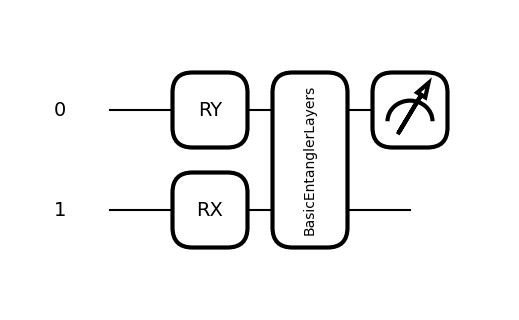

In [11]:
qml.draw_mpl(circuito_quantico)(X_angulos, peso) #desenhando o circuito quantico

## Função de Perda — Erro Quadrático Médio (MSE)

A saída do circuito é ajustada para probabilidade:

$$
\hat{y}_i = \frac{f_\theta(x_i) + 1}{2}
$$

onde $f_\theta(x_i) \in [-1,1]$.

A função de perda utilizada é:

$$
\mathcal{L}(\theta) =
\frac{1}{N}
\sum_{i=1}^{N}
\left(
y_i - \hat{y}_i
\right)^2
$$

Forma expandida:

$$
\mathcal{L}(\theta) =
\frac{1}{N}
\sum_{i=1}^{N}
\left(
y_i -
\frac{f_\theta(x_i) + 1}{2}
\right)^2
$$

In [ ]:

def perda(alte, X_angulo, y): #funcao de perda, que calcula a media do erro quadratico entre as previsoes do modelo e os valores reais
    preds = []
    for i in range(len(X_angulo)):
        pred_i = circuito_quantico(X_angulo[i], alte)
        pred_i = (pred_i + 1)/2  #TRANFORMANDO EM PROBABILIDADE ENTRE 0 E 1, POIS O MODELO RETORNA VALORES ENTRE -1 E 1
        preds.append(pred_i)
        
    preds = np.array(preds)
    loss = np.mean((y - preds) ** 2)

    return loss


## Otimização
$$
\text{Atualização clássica dos parâmetros a partir de um critério de custo}
$$


### treinamento do modelo usando o adamoptmizer

In [ ]:
opt = qml.AdamOptimizer(stepsize=0.05) #otimizador Adam, que é um método de otimização estocástica baseado em gradiente, amplamente utilizado para treinamento de modelos de aprendizado de máquina, incluindo redes neurais e circuitos quânticos. Ele combina as vantagens do método de momento e do método de adaptação de taxa de aprendizado, ajustando dinamicamente a taxa de aprendizado para cada parâmetro com base nas estimativas dos momentos de primeira e segunda ordem dos gradientes.

print(f"parametro alter inicial: {peso}")
history_loss = [] #lista para armazenar a perda em cada época, para análise posterior da convergência do modelo
epocas = 50 # n de vezes q o modelo vai passar por todo o conjunto de treinamento, atualizando os pesos a cada vez

for epoca in range(epocas):
    peso = opt.step(lambda p: perda(p, X_train, y_train), peso) #atualizando os pesos utilizando o otimizador Adam, que minimiza a funcao de perda definida anteriormente
    loss = perda(peso, X_train, y_train) #calculando a perda atualizada com os novos pesos
    history_loss.append(loss) #armazenando a perda atual na lista de histórico de perdas
    print(f"Epoch {epoca}: Loss = {loss :.4f}")


parametro alter inicial: [[ 0.02789413 -0.07666708]]
Epoch 0: Loss = 0.7404
Epoch 1: Loss = 0.7375
Epoch 2: Loss = 0.7332
Epoch 3: Loss = 0.7276
Epoch 4: Loss = 0.7207
Epoch 5: Loss = 0.7123
Epoch 6: Loss = 0.7025
Epoch 7: Loss = 0.6913
Epoch 8: Loss = 0.6787
Epoch 9: Loss = 0.6647
Epoch 10: Loss = 0.6493
Epoch 11: Loss = 0.6327
Epoch 12: Loss = 0.6149
Epoch 13: Loss = 0.5959
Epoch 14: Loss = 0.5758
Epoch 15: Loss = 0.5548
Epoch 16: Loss = 0.5329
Epoch 17: Loss = 0.5103
Epoch 18: Loss = 0.4871
Epoch 19: Loss = 0.4636
Epoch 20: Loss = 0.4397
Epoch 21: Loss = 0.4157
Epoch 22: Loss = 0.3917
Epoch 23: Loss = 0.3680
Epoch 24: Loss = 0.3446
Epoch 25: Loss = 0.3216
Epoch 26: Loss = 0.2994
Epoch 27: Loss = 0.2778
Epoch 28: Loss = 0.2571
Epoch 29: Loss = 0.2374
Epoch 30: Loss = 0.2186
Epoch 31: Loss = 0.2010
Epoch 32: Loss = 0.1845
Epoch 33: Loss = 0.1691
Epoch 34: Loss = 0.1549
Epoch 35: Loss = 0.1417
Epoch 36: Loss = 0.1297
Epoch 37: Loss = 0.1188
Epoch 38: Loss = 0.1088
Epoch 39: Loss = 0.09

## Medição
$$
\text{Extração de informação clássica por meio de observáveis}
$$


### Testando Resultado

In [24]:
y_test = np.array(y_test).ravel()
y_pred = np.array(y_pred).ravel()
y_pred_prob = np.array(y_pred_prob).ravel()

In [ ]:

# Se circuito_quantico retorna <Z> em [-1,1]
# então (1 - <Z>) / 2 mapeia para [0,1]
y_pred_prob = np.array([
    ((circuito_quantico(xi, peso) + 1) / 2).item()
    for xi in X_test
])

# Se p > 0.5 → classe 1
y_pred = (y_pred_prob > 0.5).astype(int)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob))


print("\nRelatório Completo:")
print(classification_report(y_test, y_pred))


Acurácia: 1.0
ROC-AUC: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Balanced Accuracy: 1.0
PR-AUC: 0.9999999999999999

Relatório Completo:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        46

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## Visualização da Convergência da Loss

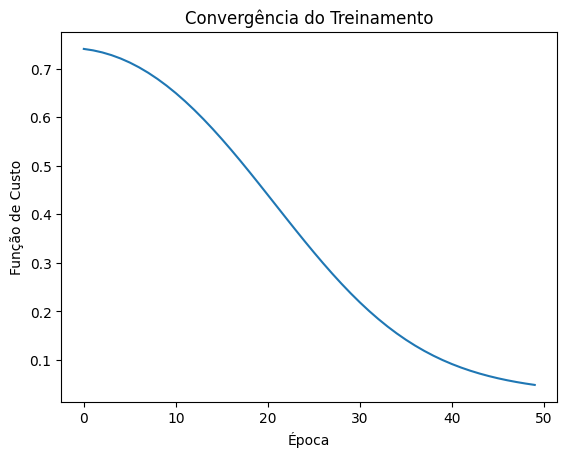

In [15]:
plt.figure()
plt.plot(history_loss)
plt.xlabel("Época")
plt.ylabel("Função de Custo")
plt.title("Convergência do Treinamento")
plt.show()


# Visualização do limite de decisão do modelo Quântico no dataset linear

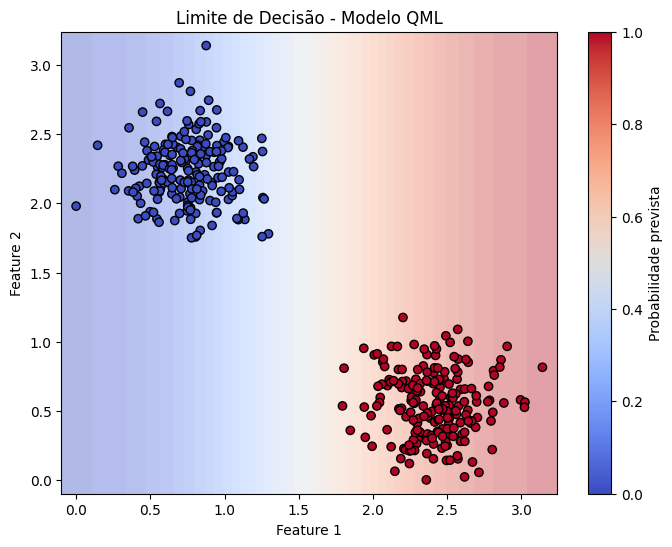

In [26]:

# Definindo limites do plano
x_min, x_max = X_angulos[:,0].min() - 0.1, X_angulos[:,0].max() + 0.1
y_min, y_max = X_angulos[:,1].min() - 0.1, X_angulos[:,1].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Junta os pontos da malha
grid = np.c_[xx.ravel(), yy.ravel()]

# Predição na malha
Z = []
for point in grid:
    pred = circuito_quantico(point, peso)
    pred = (pred + 1) / 2   # normaliza se estiver usando PauliZ
    Z.append(pred)

Z = np.array(Z)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=50, alpha=0.4, cmap='coolwarm')
plt.scatter(X_angulos[:,0], X_angulos[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Limite de Decisão - Modelo QML")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Probabilidade prevista")
plt.show()


### O modelo apresentou desempenho perfeito no dataset linearmente separável, atingindo acurácia de 100% e métricas ideais (ROC-AUC, Precision, Recall e F1-score iguais a 1.0). Isso indica que o circuito quântico foi capaz de aprender corretamente a fronteira de decisão linear presente nos dados. O resultado é consistente com a natureza do conjunto make_blobs, que possui separação clara entre as classes.

### Datasets Não-Lineares para Avaliação
$$
\text{Conjuntos de dados não-lineares utilizados para avaliar o desempenho do modelo}
$$


In [27]:
x_not_linear, y = make_moons(n_samples=400,noise=0.1,random_state=42)

## Visualização dos dados 

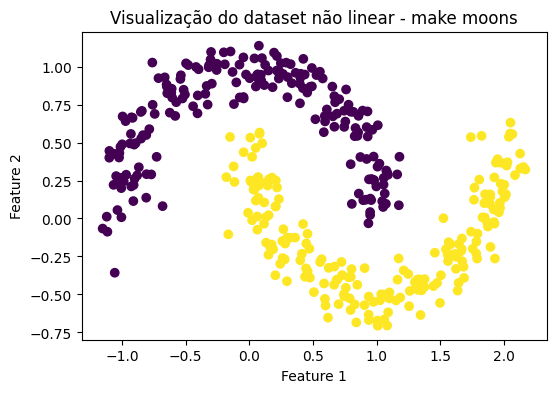

In [28]:
plt.figure(figsize=(6, 4))

plt.scatter(x_not_linear[:, 0], x_not_linear[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Visualização do dataset não linear - make moons")

plt.show()

### Reescalando os dados originais para o intervalo angular [0, π], convertendo cada feature proporcionalmente em radianos, dessa forma permitindo rotações estáveis e adequadas nos qubits durante o embedding quântico

In [29]:
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_angulos = scaler.fit_transform(x_not_linear)

### Devido ao uso de um conjunto de dados não linear (make_moons), os pesos do circuito quântico foram ajustados para aumentar a capacidade de representação do modelo, permitindo melhor aprendizado de fronteiras de decisão curvas.

In [30]:
import pennylane.numpy as np

n_layers = 6
peso = np.random.uniform(0, np.pi, (n_layers, 2, 3), requires_grad=True)
print("Peso inicial:", peso)       

Peso inicial: [[[2.15809502 1.55922386 0.40352841]
  [1.66880522 0.53715913 1.62790365]]

 [[0.27673271 2.1757984  1.69982315]
  [3.01313985 2.24378106 0.47144078]]

 [[2.26394411 2.83545069 2.21039922]
  [1.94888523 1.87502075 0.77088224]]

 [[2.36670488 1.01607064 1.48459744]
  [1.91850006 2.09369432 1.00680309]]

 [[1.050163   3.00618138 2.08500873]
  [2.76584535 2.15643215 1.16166623]]

 [[0.32665717 0.76762091 3.08427329]
  [0.97902934 1.75136205 2.67692086]]]


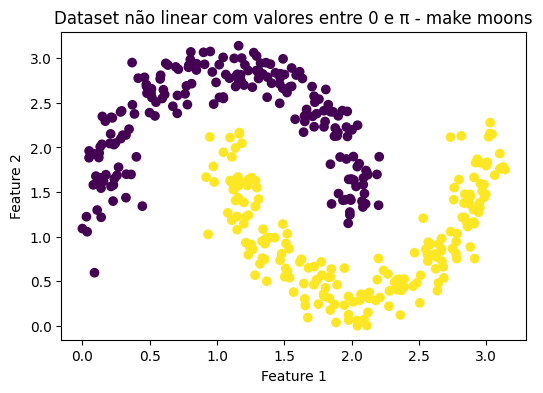

In [31]:
plt.figure(figsize=(6, 4))

plt.scatter(X_angulos[:, 0], X_angulos[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset não linear com valores entre 0 e π - make moons")

plt.show()

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_angulos, y,
    test_size=0.2,      # 20% teste
    random_state=42,    # reprodutibilidade
    shuffle=True        # embaralhar
)

\subsection{Função de Perda}

A função de perda utilizada é a Binary Cross-Entropy, apropriada para problemas de classificação binária. Como o circuito quântico retorna valores no intervalo $[-1,1]$, realiza-se inicialmente a normalização para o intervalo $[0,1]$:

\begin{equation}
\hat{y}_i = \frac{f(x_i) + 1}{2}
\end{equation}

A função de perda é então definida como:

\begin{equation}
\mathcal{L} = - \frac{1}{N} \sum_{i=1}^{N}
\left[
y_i \log(\hat{y}_i) +
(1 - y_i)\log(1 - \hat{y}_i)
\right]
\end{equation}

onde $y_i$ representa o rótulo verdadeiro, $\hat{y}_i$ a probabilidade prevista pelo modelo e $N$ o número total de amostras.

Para evitar instabilidades numéricas associadas ao cálculo de $\log(0)$, adiciona-se um pequeno termo $\varepsilon$ às probabilidades.


In [33]:
def perda(peso, X_angulo, y):
    preds = []
    for i in range(len(X_angulo)):
        pred_i = circuito_quantico(X_angulo[i], peso)
        pred_i = (pred_i + 1) / 2  # [-1,1] → [0,1]
        preds.append(pred_i)

    preds = np.array(preds)
    eps = 1e-8
    loss = -np.mean(
        y * np.log(preds + eps) +
        (1 - y) * np.log(1 - preds + eps)
    )
    return loss


In [34]:
dev = qml.device("default.qubit", wires=2) #criando um dispositivo quantico com 2 qubits 
n_qubits = 2

## Aumento da Complexidade do Circuito

### Devido à natureza não linear do conjunto de dados make_moons, foi necessário aumentar a complexidade do circuito quântico variacional. Para isso, adicionaram-se camadas adicionais de rotações parametrizadas e operações de emaranhamento, ampliando a capacidade expressiva do modelo. Essa modificação permite a aprendizagem de fronteiras de decisão não lineares, adequadas à estrutura dos dados.

In [35]:
@qml.qnode(dev, interface="autograd")
def circuito_quantico(x, peso):

    for l in range(peso.shape[0]): #aumentando a complexidade do circuito, aplicando mais camadas de rotação e emaranhamento, o que permite ao modelo aprender padrões mais complexos nos dados
        #aplicando rotação nos dois Qubits com os valores da base de dados em forma de radianos
        qml.RY(x[0], wires=0)
        qml.RY(x[1], wires=1)

            # Parte treinável (mais profunda)
        qml.StronglyEntanglingLayers(peso[l:l+1], wires=[0,1])


    return qml.expval(qml.PauliZ(0))


\subsection{Ansatz: StronglyEntanglingLayers}

Para o dataset não linear make_moons, foi utilizado um ansatz mais expressivo denominado \textit{StronglyEntanglingLayers}. Essa arquitetura é composta por múltiplas camadas variacionais, cada uma contendo rotações parametrizadas seguidas de operações de emaranhamento entre os qubits.

Para cada camada $l$ e para cada qubit $i$, aplica-se uma sequência de rotações arbitrárias do tipo:

\begin{equation}
U_{l,i} = RZ(\theta_{l,i,1}) \, RY(\theta_{l,i,2}) \, RZ(\theta_{l,i,3})
\end{equation}

onde $\theta_{l,i,k}$ são parâmetros treináveis do modelo.

Após a aplicação das rotações em todos os qubits, realiza-se o emaranhamento através de portas CNOT, promovendo correlação quântica entre os estados. Para dois qubits, a operação de emaranhamento pode ser representada por:

\begin{equation}
U_{\text{ent}} = \text{CNOT}_{0 \rightarrow 1}
\end{equation}

Assim, uma camada completa do circuito é dada por:

\begin{equation}
U^{(l)} = 
\left(
\prod_{i=1}^{n}
RZ(\theta_{l,i,1}) \, RY(\theta_{l,i,2}) \, RZ(\theta_{l,i,3})
\right)
\cdot
U_{\text{ent}}
\end{equation}

O circuito total com $L$ camadas é então definido como:

\begin{equation}
U(\Theta) = \prod_{l=1}^{L} U^{(l)}
\end{equation}

onde $\Theta$ representa o conjunto completo de parâmetros treináveis.

O aumento do número de camadas ($L$) amplia a capacidade expressiva do modelo, permitindo representar fronteiras de decisão não lineares, adequadas ao comportamento geométrico do dataset \textit{make\_moons}.

# Visualização do circuito

(<Figure size 1500x300 with 1 Axes>, <Axes: >)

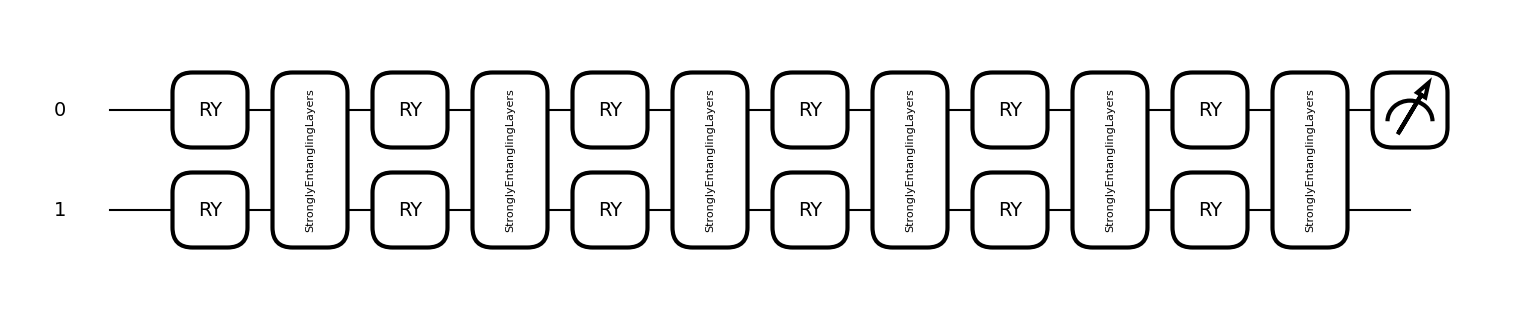

In [36]:
qml.draw_mpl(circuito_quantico)(X_angulos, peso) #desenhando o circuito quantico

## Treinamento do modelo

In [37]:
opt = qml.AdamOptimizer(stepsize=0.05)
print(f"parametro alter inicial: {peso}") 

history_loss = []
epocas = 50

for epoca in range(epocas):
    peso = opt.step(lambda p: perda(p, X_train, y_train), peso) #atualizando os pesos utilizando o otimizador Adam, que minimiza a funcao de perda definida anteriormente

    loss = perda(peso, X_train, y_train) #calculando a perda atualizada com os novos pesos
    history_loss.append(loss)
    
    print(f"Epoch {epoca}: Loss = {loss:.4f}")


parametro alter inicial: [[[2.15809502 1.55922386 0.40352841]
  [1.66880522 0.53715913 1.62790365]]

 [[0.27673271 2.1757984  1.69982315]
  [3.01313985 2.24378106 0.47144078]]

 [[2.26394411 2.83545069 2.21039922]
  [1.94888523 1.87502075 0.77088224]]

 [[2.36670488 1.01607064 1.48459744]
  [1.91850006 2.09369432 1.00680309]]

 [[1.050163   3.00618138 2.08500873]
  [2.76584535 2.15643215 1.16166623]]

 [[0.32665717 0.76762091 3.08427329]
  [0.97902934 1.75136205 2.67692086]]]
Epoch 0: Loss = 0.8210
Epoch 1: Loss = 0.6480
Epoch 2: Loss = 0.5268
Epoch 3: Loss = 0.4368
Epoch 4: Loss = 0.3648
Epoch 5: Loss = 0.3069
Epoch 6: Loss = 0.2627
Epoch 7: Loss = 0.2317
Epoch 8: Loss = 0.2125
Epoch 9: Loss = 0.2021
Epoch 10: Loss = 0.1967
Epoch 11: Loss = 0.1928
Epoch 12: Loss = 0.1880
Epoch 13: Loss = 0.1819
Epoch 14: Loss = 0.1751
Epoch 15: Loss = 0.1686
Epoch 16: Loss = 0.1628
Epoch 17: Loss = 0.1579
Epoch 18: Loss = 0.1535
Epoch 19: Loss = 0.1489
Epoch 20: Loss = 0.1438
Epoch 21: Loss = 0.1380
E

## Visualização da Convergência da Loss

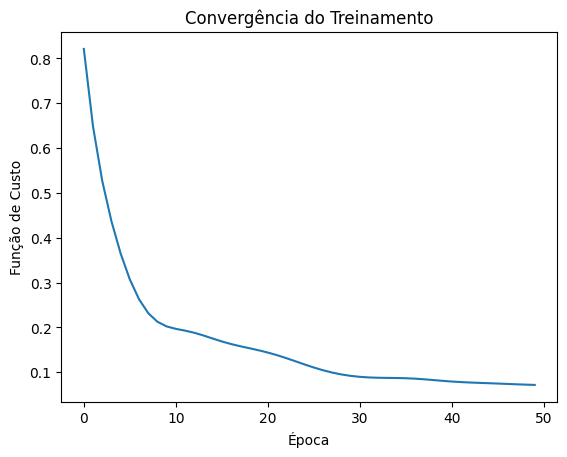

In [38]:
plt.figure()
plt.plot(history_loss)
plt.xlabel("Época")
plt.ylabel("Função de Custo")
plt.title("Convergência do Treinamento")
plt.show()


## Resultados após o treinamento 

In [ ]:
y_test = np.array(y_test).ravel() # Convertendo y_test para um array unidimensional, garantindo que seja do formato correto para as métricas de avaliação
y_pred = np.array(y_pred).ravel()
y_pred_prob = np.array(y_pred_prob).ravel()

In [ ]:
y_pred_prob = np.array([ # Se circuito_quantico retorna <Z> em [-1,1]
    (1 + circuito_quantico(xi, peso)) / 2 # normaliza se estiver usando PauliZ
    for xi in X_test # iterando sobre os dados de teste para obter as previsões de probabilidade do modelo para cada ponto de teste, utilizando o circuito quântico treinado
])

y_pred = (y_pred_prob > 0.5).astype(int)


print("Acurácia:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob))



print("\nRelatório Completo:")
print(classification_report(y_test, y_pred))


Acurácia: 1.0
ROC-AUC: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
Balanced Accuracy: 1.0
PR-AUC: 1.0

Relatório Completo:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



# Visualização do limite de decisão do modelo Quântico no dataset não linear

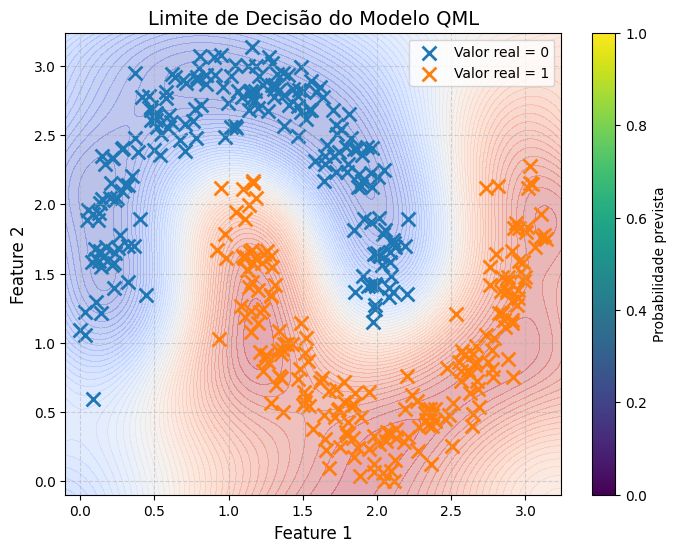

In [41]:
# Definindo limites do plano
x_min, x_max = X_angulos[:,0].min() - 0.1, X_angulos[:,0].max() + 0.1
y_min, y_max = X_angulos[:,1].min() - 0.1, X_angulos[:,1].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Criando grade de pontos
grid = np.c_[xx.ravel(), yy.ravel()]

# Predição na malha
Z = []
for point in grid:
    pred = circuito_quantico(point, peso)
    pred = (pred + 1) / 2
    Z.append(pred)

Z = np.array(Z)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

# Fundo com limite de decisão
plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.35)

# Pontos reais
for label in np.unique(y):
    plt.scatter(
        X_angulos[y==label,0], X_angulos[y==label,1],
        marker='x', s=100, linewidths=2,
        label=f'Valor real = {label}'
    )

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Limite de Decisão do Modelo QML', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.colorbar(label='Probabilidade prevista')
plt.show()


### para o dataset não linear (make_moons), foi necessário aumentar a profundidade do circuito, aplicando múltiplas camadas de rotação e utilizando StronglyEntanglingLayers. Esse aumento na expressividade do modelo permitiu aprender fronteiras de decisão curvas, adequadas à geometria dos dados.

### Os resultados indicam que a capacidade de representação do circuito quântico está diretamente relacionada à sua profundidade e ao tipo de camada de emaranhamento utilizada.